# Model Training & Model Selection
**Project**: House Price Prediction  
**Notebook**: `04_Model_Training.ipynb`  
**Target**: Predict House `SalePrice` and compare 3 models (linear, tree-based, non-linear) using MAE, RMSE and $R^2$.

In [13]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
print("All modeling libraries imported successfully!")

All modeling libraries imported successfully!


## 1. Load Preprocessed Feature Matrices

In [14]:
processed_dir = os.path.join("..", "data", "processed")
if not os.path.exists(processed_dir):
    processed_dir = os.path.join("data", "processed")

X_train = pd.read_csv(os.path.join(processed_dir, "X_train.csv"))
X_test = pd.read_csv(os.path.join(processed_dir, "X_test.csv"))
y_train = pd.read_csv(os.path.join(processed_dir, "y_train.csv")).values.ravel()
y_test = pd.read_csv(os.path.join(processed_dir, "y_test.csv")).values.ravel()

print("Datasets loaded successfully!")
print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape: ", y_test.shape)

Datasets loaded successfully!
X_train shape: (1164, 231)
X_test shape:  (292, 231)
y_train shape: (1164,)
y_test shape:  (292,)


## 2. Model Training

Three models, one per cell. All of them predict `log1p(SalePrice)` and convert back to dollars, which stabilises the skewed price distribution.

### Model 1 — Linear model: Ridge Regression

In [15]:
ridge_model = TransformedTargetRegressor(
    regressor=Ridge(alpha=10.0, random_state=42),
    func=np.log1p,
    inverse_func=np.expm1
)
ridge_model.fit(X_train, y_train)

ridge_pred_train = ridge_model.predict(X_train)
ridge_pred_test = ridge_model.predict(X_test)
print("Ridge Regression trained. Test R2:", round(r2_score(y_test, ridge_pred_test), 4))

Ridge Regression trained. Test R2: 0.9248


### Model 2 — Tree-based model: Random Forest

In [16]:
rf_model = TransformedTargetRegressor(
    regressor=RandomForestRegressor(n_estimators=300, max_depth=15, random_state=42, n_jobs=-1),
    func=np.log1p,
    inverse_func=np.expm1
)
rf_model.fit(X_train, y_train)

rf_pred_train = rf_model.predict(X_train)
rf_pred_test = rf_model.predict(X_test)
print("Random Forest trained. Test R2:", round(r2_score(y_test, rf_pred_test), 4))

Random Forest trained. Test R2: 0.8927


### Model 3 — Non-linear model: Support Vector Regressor (RBF kernel)

In [17]:
# SVR is distance-based, so the features are standardised inside the pipeline
svr_model = TransformedTargetRegressor(
    regressor=make_pipeline(StandardScaler(), SVR(kernel="rbf", C=10, epsilon=0.01, gamma="scale")),
    func=np.log1p,
    inverse_func=np.expm1
)
svr_model.fit(X_train, y_train)

svr_pred_train = svr_model.predict(X_train)
svr_pred_test = svr_model.predict(X_test)
print("SVR trained. Test R2:", round(r2_score(y_test, svr_pred_test), 4))

SVR trained. Test R2: 0.7816


## 3. Model Comparison

In [ ]:
models = {
    "Ridge Regression (Linear)": ridge_model,
    "Random Forest (Tree-based)": rf_model,
    "SVR RBF (Non-linear)": svr_model,
}

results = []
for name, model in models.items():
    y_pred_tr = model.predict(X_train)
    y_pred_te = model.predict(X_test)

    results.append({
        "Model Name": name,
        "MAE": mean_absolute_error(y_test, y_pred_te),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_te)),
        "Train R2": r2_score(y_train, y_pred_tr),
        "Test R2": r2_score(y_test, y_pred_te),
    })

comparison_df = pd.DataFrame(results).sort_values(by="Test R2", ascending=False).reset_index(drop=True)
comparison_df

,Model Name,MAE,RMSE,Train R2,Test R2
0,Ridge Regression (Linear),14098.127567,19861.850330,0.948116,0.924836
1,Random Forest (Tree-based),16252.893460,23727.102272,0.984402,0.892734
2,SVR RBF (Non-linear),19799.296639,33854.177694,0.999343,0.781628


## 4. Visualize Test R² Score

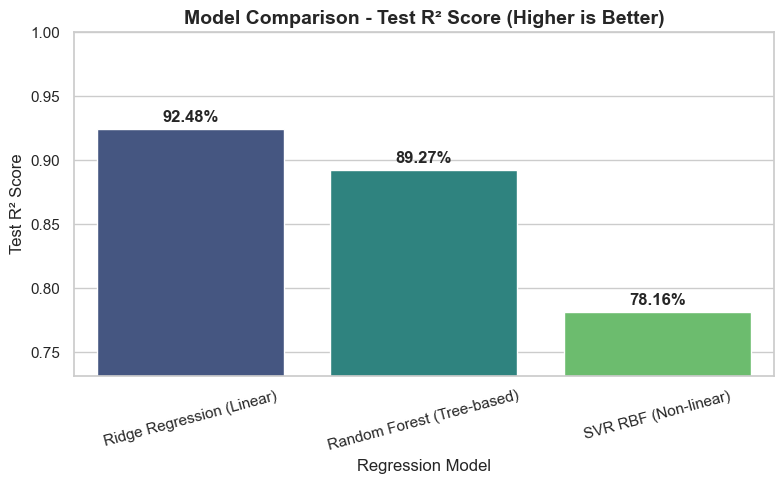

In [19]:
plt.figure(figsize=(8, 5))
sns.barplot(data=comparison_df, x="Model Name", y="Test R2", hue="Model Name", palette="viridis", legend=False)
plt.title("Model Comparison - Test R² Score (Higher is Better)", fontsize=14, fontweight="bold")
plt.xlabel("Regression Model", fontsize=12)
plt.ylabel("Test R² Score", fontsize=12)
plt.ylim(min(0.8, comparison_df["Test R2"].min() - 0.05), 1.0)
plt.xticks(rotation=15)

for idx, row in comparison_df.iterrows():
    plt.text(idx, row["Test R2"] + 0.005, f"{row['Test R2']*100:.2f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

## 5. Save Best Model Artifact

In [20]:
best_model_name = comparison_df.iloc[0]["Model Name"]
best_model_obj = models[best_model_name]

models_dir = os.path.join("..", "models")
if not os.path.exists(models_dir):
    models_dir = os.path.join("models")
os.makedirs(models_dir, exist_ok=True)

model_path = os.path.join(models_dir, "best_model.pkl")
joblib.dump(best_model_obj, model_path)

print(f"Best Performing Model ('{best_model_name}') saved to {model_path}!")

Best Performing Model ('Ridge Regression (Linear)') saved to ..\models\best_model.pkl!
